## Babynames.ipynb
# Author Cathal Redmond 7 April 2026
# Goal: Generate a line chart that shows the percentage share of the most popular boys names in Ireland from the years 1964 to 2025, using data from the CSO website. 


In [ ]:
##Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##define the file location
boysnames = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/VSA50/CSV/1.0/"
girlsnames = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/VSA60/CSV/1.0/"

##read the data into a dataframe
boysnames = pd.read_csv(boysnames)
girlsnames = pd.read_csv(girlsnames)


##drop the first three columns which are not needed for analysis
boysnames = boysnames.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'UNIT'])
girlsnames = girlsnames.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'UNIT'])

# add a new column to each dataframe to indicate the gender
boysnames['gender'] = 'boy'
girlsnames['gender'] = 'girl'   

#combine the two dataframes into one dataframe called 'babynames'
babynames = pd.concat([boysnames, girlsnames])  

# convert nan values in column 'value' to 0 and 
babynames = babynames.fillna(0)
print(babynames.head())

   Year  C02512V04117 Boys Names  VALUE gender  C02514V04120 Girls Names
0  1964        2677.0        A J    0.0    boy           0.0           0
1  1964        1232.0       A.J.    0.0    boy           0.0           0
2  1964        2755.0      Aahan    0.0    boy           0.0           0
3  1964        2240.0      Aahil    0.0    boy           0.0           0
4  1964        1001.0      Aaran    0.0    boy           0.0           0


In [80]:
##covert the data type to integer for the 'VALUE' column
babynames['VALUE'] = babynames['VALUE'].astype(int)

## create a new column with the sum or total of the 'VALUE' column for each unique value in the 'Year' column
babynames['Total'] = babynames.groupby('Year')['VALUE'].transform('sum')

## create a new column with the percentage of each value in the 'VALUE' column compared to the total for that year
babynames['Percentage'] = babynames['VALUE'] / babynames['Total'] * 100

## create a new colummn with the ranking of each value in the 'VALUE' column for each unique value in the 'Year' column
babynames['Rank'] = babynames.groupby('Year')['VALUE'].rank(ascending=False)  

##display the first few rows of the dataframe
print(babynames.head())



   Year  C02512V04117 Boys Names  VALUE gender  C02514V04120 Girls Names  \
0  1964        2677.0        A J      0    boy           0.0           0   
1  1964        1232.0       A.J.      0    boy           0.0           0   
2  1964        2755.0      Aahan      0    boy           0.0           0   
3  1964        2240.0      Aahil      0    boy           0.0           0   
4  1964        1001.0      Aaran      0    boy           0.0           0   

    Total  Percentage    Rank  
0  187377         0.0  7306.5  
1  187377         0.0  7306.5  
2  187377         0.0  7306.5  
3  187377         0.0  7306.5  
4  187377         0.0  7306.5  


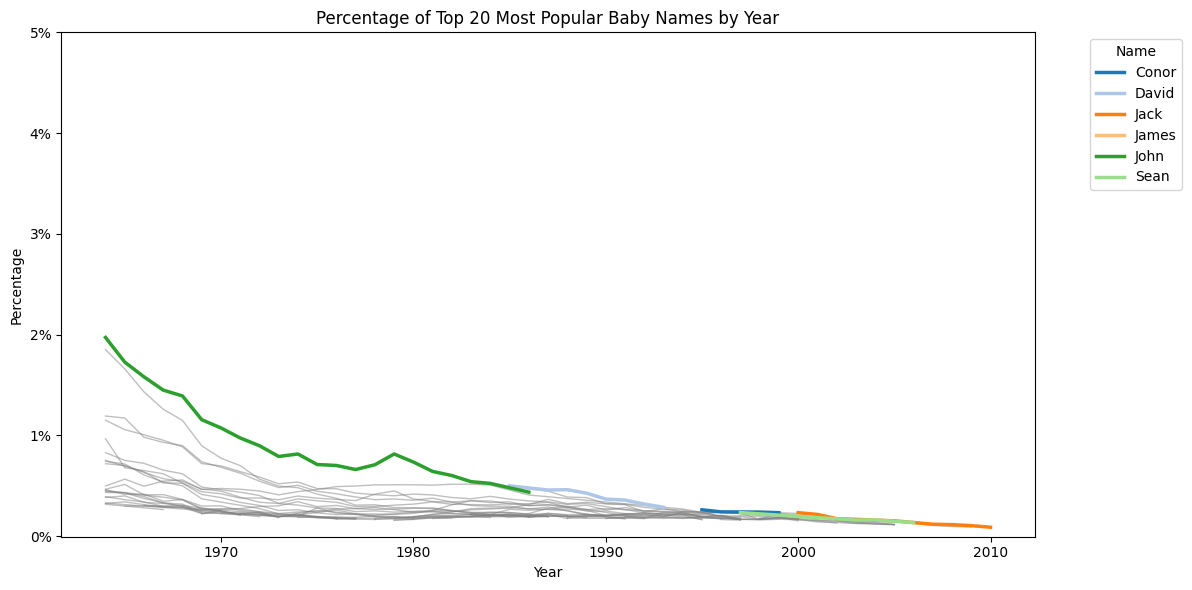

In [81]:
# Create a line chart showing the percentage of the top 10 most popular baby names for each year. Show the names in the legend and label the axes and title of the chart. use seaborn for the line chart. use a different color for each name in the line chart. show the legend outside the plot area on the right side of the chart. display the names sorted in alphabetical order in the legend. only show the top ranked name as coloured lines and the rest as grey lines for each year. use tight_layout to adjust the layout of the chart and make sure the legend does not overlap with the plot area. display the y axis as an exponential scale.         

# Filter the dataframe to only include the top 20 most popular baby names for each year
top_20 = babynames[babynames['Rank'] <= 20]

# Create a line chart using seaborn
plt.figure(figsize=(12, 6))
top_20 = top_20.assign(
    Name=top_20['Boys Names'].fillna('').replace({0: '', 0.0: ''}).astype(str)
         + top_20['Girls Names'].fillna('').replace({0: '', 0.0: ''}).astype(str)
)
top_20['Name'] = top_20['Name'].str.strip()
top_20 = top_20[top_20['Name'] != '']

top1_names = sorted(top_20.loc[top_20['Rank'] == 1, 'Name'].unique())
palette = dict(zip(top1_names, sns.color_palette('tab20', n_colors=len(top1_names))))

sns.lineplot(
    data=top_20[top_20['Rank'] != 1],
    x='Year', y='Percentage',
    units='Name', estimator=None,
    color='grey', linewidth=1, alpha=0.5
)

sns.lineplot(
    data=top_20[top_20['Rank'] == 1],
    x='Year', y='Percentage',
    hue='Name', hue_order=top1_names,
    palette=palette, estimator=None, linewidth=2.5
)

# Set the title and labels
plt.title('Percentage of Top 20 Most Popular Baby Names by Year')
plt.xlabel('Year')
plt.ylabel('Percentage')

#show the numbers 0-5 on the y axis in percentage format
plt.yticks(np.arange(0, 6, 1), ['0%', '1%', '2%', '3%', '4%', '5%'])        

# Move the legend outside the plot area on the right side
plt.legend(title='Name', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Set the y-axis to exponential scale
#plt.yscale('log')

# Show the plot
plt.show()  

Year
1964    0.957522
1965    0.955688
1966    0.953699
1967    0.951987
1968    0.952023
          ...   
2021    0.881367
2022    0.878653
2023    0.880038
2024    0.877423
2025    0.875694
Name: VALUE, Length: 62, dtype: float64


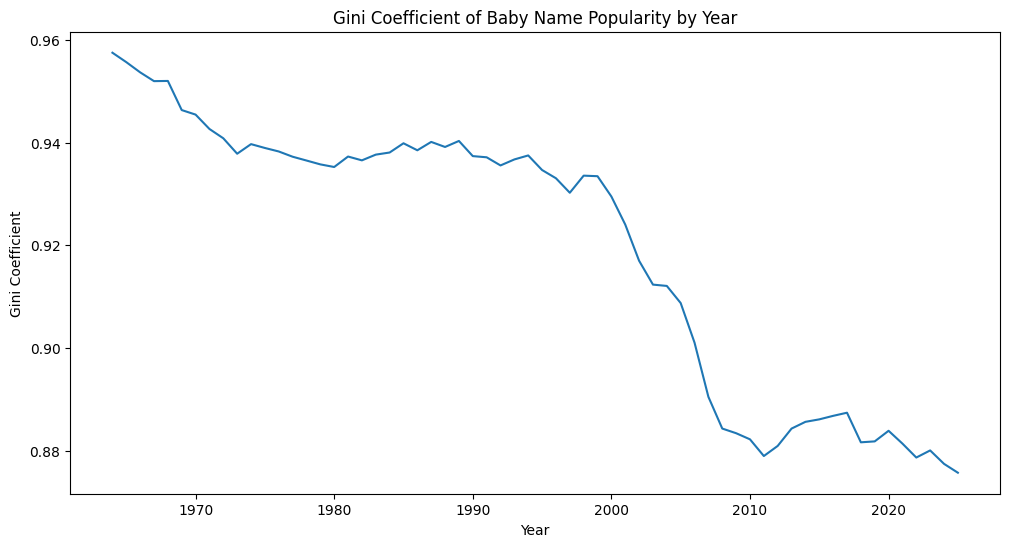

In [82]:
# calculate the ginini coefficient for the 'VALUE' column for each year
def gini_coefficient(x):
    # Sort the values in ascending order
    sorted_x = np.sort(x)
    n = len(x)
    cumulative_x = np.cumsum(sorted_x)
    gini = (n + 1 - 2 * np.sum(cumulative_x) / cumulative_x[-1]) / n
    return gini 
gini_by_year = babynames.groupby('Year')['VALUE'].apply(gini_coefficient)
print(gini_by_year)

# plot the gini coefficient for each year as a line chart using seaborn    
plt.figure(figsize=(12, 6))
sns.lineplot(x=gini_by_year.index, y=gini_by_year.values)
plt.title('Gini Coefficient of Baby Name Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Gini Coefficient')
plt.show()  